In [535]:
import kagglehub
import os
import pandas as pd


In [536]:

# # Download latest version
path = kagglehub.dataset_download("kathir1k/youtube-influencers-data")

print(os.path.join(path, os.listdir(path)[0]))



/Users/emirysaglam/.cache/kagglehub/datasets/kathir1k/youtube-influencers-data/versions/2/Youtube Influencer Analysis - Updated.csv


In [537]:
import chardet

with open(os.path.join(path, os.listdir(path)[0]), "rb") as f:
    result = chardet.detect(f.read(10000))

print(result['encoding'])



Windows-1252


In [538]:
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]), encoding=result['encoding'])
df[["Video Link", "Channel URL", "Date of Video Upload", "Creator Name"]]

,Video Link,Channel URL,Date of Video Upload,Creator Name
0,https://www.youtube.com/watch?v=_0fUOJ55gis,https://www.youtube.com/c/sriharick,7/29/2022,srihari ck
1,https://www.youtube.com/watch?v=_70MSLPRfZI,https://www.youtube.com/c/ChaibisketTelugu,5/22/2022,Chai Bisket
2,https://www.youtube.com/watch?v=_8gfCdt3H00&t=87s,https://www.youtube.com/channel/UCcIUnCsBfONvb...,2/9/2021,Virda Warsi
3,https://www.youtube.com/watch?v=_CkFNJgKsFs,https://www.youtube.com/c/trtworld,9/13/2022,TRT
4,https://www.youtube.com/watch?v=_GFkHA5EZdE,Vogue - YouTube,3/21/2017,Vogue
...,...,...,...,...
900,https://www.youtube.com/watch?v=GS18WawA-t0,https://www.youtube.com/c/SahilOnlineTVnews,9/29/2022,Sahil Online TV News
901,https://www.youtube.com/watch?v=_tc_APkjH2Q,https://www.youtube.com/sahilonline,8/6/2017,Sahil Online TV News
902,https://www.youtube.com/watch?v=Xfj4osSYfhU,https://www.youtube.com/sahilonline,1/3/2021,Sahil Online Bhatkal
903,https://www.youtube.com/watch?v=mGEHqwVz0eI,https://www.youtube.com/sahilonline,3/6/2022,Sahil Online Bhatkal


## Data Manupilation

In [539]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Video Link                             905 non-null    object 
 1   Video Views                            905 non-null    object 
 2   Video Title                            905 non-null    object 
 3   Channel URL                            905 non-null    object 
 4   Creator Name                           894 non-null    object 
 5   Creator Gender                         591 non-null    object 
 6   Total Channel Subcribers               905 non-null    object 
 7   Total Chanel Views                     905 non-null    object 
 8   Duration of Video                      905 non-null    object 
 9   Duration in Seconds                    905 non-null    object 
 10  Date of Video Upload                   905 non-null    object 
 11  No of 

In [540]:
df.drop(columns=['Video Link','Intern Who Collected the Data'], inplace=True)

### String to Numeric

In [541]:
df[["Video Views","Total Channel Subcribers","Total Chanel Views","Duration in Seconds","No of Comments"]]

,Video Views,Total Channel Subcribers,Total Chanel Views,Duration in Seconds,No of Comments
0,"146,059",40200,7964284,"1,841.00",419
1,"231,969",920000,137535681,864.00,189
2,878,458,72945,492.00,0
3,"9,965",1680000,541653219,66.00,77
4,"39,780,561",12100000,3600496171,460.00,28221
...,...,...,...,...,...
900,"6,892",594000,129926690,827.00,15
901,"16,554",594000,129926690,404.00,0
902,"32,798",23500,5104872,384.00,0
903,"1,503",23500,5104872,279.00,0


In [542]:

df['Video Views'] = df['Video Views'].str.replace(',', '')
df['Video Views'] = pd.to_numeric(df['Video Views'], errors='coerce')


df['Total Channel Subcribers'] = df['Total Channel Subcribers'].str.replace(',', '')
df['Total Channel Subcribers'] = pd.to_numeric(df['Total Channel Subcribers'], errors='coerce')


df['Total Chanel Views'] = df['Total Chanel Views'].str.replace(',', '')
df['Total Chanel Views'] = pd.to_numeric(df['Total Chanel Views'], errors='coerce')


df['Duration in Seconds'] = df['Duration in Seconds'].str.replace(',', '')
df['Duration in Seconds'] = pd.to_numeric(df['Duration in Seconds'], errors='coerce')

df['No of Comments'] = df['No of Comments'].str.replace(',', '')
df['No of Comments'] = pd.to_numeric(df['No of Comments'], errors='coerce')



In [543]:
df['Premiered or Not'] = df['Premiered or Not'].str.strip().str.lower().map({'yes': 1, 'no': 0})

In [544]:
df.describe()

,Video Views,Total Channel Subcribers,Total Chanel Views,Duration in Seconds,No of Likes,Hashtags,No of Comments,Maximum Quality of the Video,No of Videos the Channel,No of Playlist,Premiered or Not,Community Engagement (Posts per week)
count,9.050000e+02,9.030000e+02,8.960000e+02,905.000000,9.040000e+02,905.000000,9.050000e+02,905.000000,905.000000,896.000000,905.000000,905.000000
mean,5.447910e+07,1.043915e+07,2.235640e+09,1927.761326,5.840101e+05,1.030939,4.558636e+04,1227.712707,4962.866298,82.246652,0.111602,4.516022
std,4.002179e+08,2.410166e+07,1.055352e+10,6395.720819,2.959309e+06,1.835350,4.786907e+05,419.254719,24193.140397,446.041267,0.315051,19.377195
min,2.300000e+01,3.400000e+01,3.600000e+01,0.000000,0.000000e+00,0.000000,0.000000e+00,240.000000,1.000000,0.000000,0.000000,0.000000
25%,2.013700e+05,3.270000e+05,3.599062e+07,314.000000,5.475000e+03,0.000000,2.280000e+02,1080.000000,150.000000,6.000000,0.000000,0.000000
50%,1.293867e+06,2.100000e+06,2.475236e+08,645.000000,3.250000e+04,0.000000,1.221000e+03,1080.000000,389.000000,16.000000,0.000000,1.000000
75%,9.002909e+06,9.300000e+06,1.267778e+09,1034.000000,1.845000e+05,2.000000,7.016000e+03,1080.000000,1393.000000,47.250000,0.000000,3.000000
max,7.990990e+09,3.052000e+08,2.022970e+11,62700.000000,4.900000e+07,28.000000,1.124480e+07,2160.000000,420000.000000,6000.000000,1.000000,341.000000


In [545]:
df[["Creator Name","No of Likes"]].sort_values(by="No of Likes", ascending=False)

,Creator Name,No of Likes
677,Luis Fonsi,49000000.0
328,Wiz Khalifa,39000000.0
230,Ava Max,31000000.0
440,Selena Gomez,25000000.0
518,Imagine Dragons,19000000.0
...,...,...
246,Tesery,1.0
139,Etl Qa Labs,0.0
25,Pokémon Asia Officia,0.0
104,A Girl From Uk02,0.0


### Missing Names

In [546]:
null_names = df[df["Creator Name"].isnull()][["Creator Name","Channel URL"]].copy()

In [547]:
null_names["Creator Name"] = null_names["Channel URL"].apply(lambda x: x.split("/")[-1])
null_names

,Creator Name,Channel URL
88,batmanarkham,https://www.youtube.com/c/batmanarkham
91,cokestudio,https://www.youtube.com/c/cokestudio
101,TrendMaxTV,https://www.youtube.com/c/TrendMaxTV
183,NDTV,https://www.youtube.com/c/NDTV
239,Ashstudio7HD,https://www.youtube.com/c/Ashstudio7HD
275,guardian,https://www.youtube.com/guardian
293,GQ,https://www.youtube.com/c/GQ
322,IMAGINEDRAGONSLIVEE,https://www.youtube.com/c/IMAGINEDRAGONSLIVEE
340,variant,https://www.youtube.com/variant
352,GreatBigStory,https://www.youtube.com/c/GreatBigStory


In [548]:
df.loc[df["Creator Name"].isnull(), "Creator Name"] = null_names["Creator Name"]

### Standardizing the Date Format

In [549]:
df["Date of Video Upload"] = df["Date of Video Upload"].str.replace("-", "/", regex=False)

In [550]:
# 1. Boşlukları ve görünmeyen karakterleri temizle
df["Date of Video Upload"] = df["Date of Video Upload"].astype(str).str.strip().str.replace(r"[^\x00-\x7F]+", "", regex=True)

# 2. Tarihleri tekrar çevir (gün/ay/yıl formatında olduğunu varsayarak)
df["Date of Video Upload"] = pd.to_datetime(df["Date of Video Upload"], dayfirst=True,format='mixed')




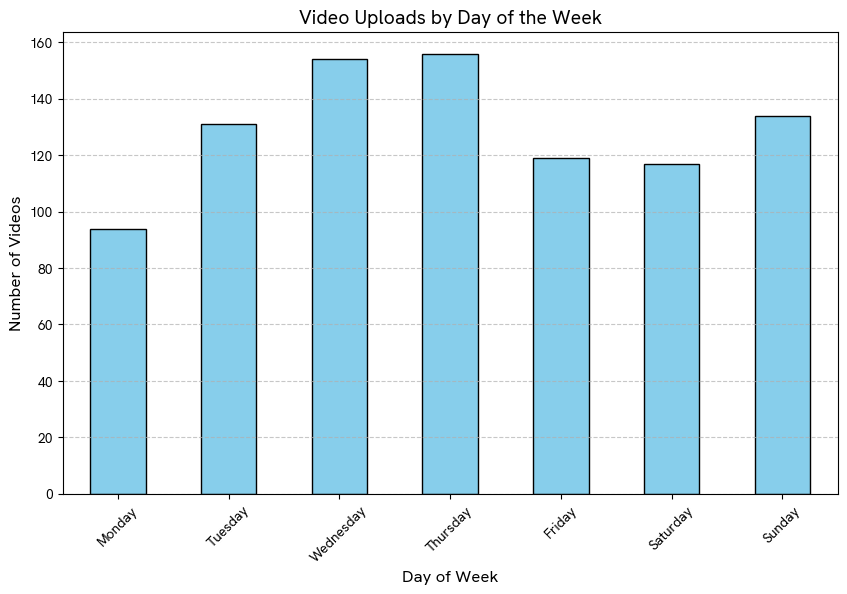

In [551]:
import matplotlib.pyplot as plt

# Tarihi datetime yap
df["Date of Video Upload"] = pd.to_datetime(df["Date of Video Upload"])

# Hafta günü çıkar (0=Monday, 6=Sunday)
df["DayOfWeek"] = df["Date of Video Upload"].dt.day_name()

# Sayım
day_counts = df["DayOfWeek"].value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

# Görselleştirme
plt.figure(figsize=(10,6))
day_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Video Uploads by Day of the Week", fontsize=14)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Number of Videos", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [552]:
day_dummies = pd.get_dummies(df["DayOfWeek"])
df = pd.concat([df, day_dummies], axis=1)
df[["Date of Video Upload","DayOfWeek","Friday","Monday","Saturday","Sunday","Thursday","Tuesday","Wednesday"]]

,Date of Video Upload,DayOfWeek,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,2022-07-29,Friday,True,False,False,False,False,False,False
1,2022-05-22,Sunday,False,False,False,True,False,False,False
2,2021-09-02,Thursday,False,False,False,False,True,False,False
3,2022-09-13,Tuesday,False,False,False,False,False,True,False
4,2017-03-21,Tuesday,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...
900,2022-09-29,Thursday,False,False,False,False,True,False,False
901,2017-06-08,Thursday,False,False,False,False,True,False,False
902,2021-03-01,Monday,False,True,False,False,False,False,False
903,2022-06-03,Friday,True,False,False,False,False,False,False


In [553]:
print(type(df["Date of Video Upload"][0]))


<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [554]:
df.sort_values("Date of Video Upload")["Date of Video Upload"]

866   2005-04-24
867   2006-10-10
446   2007-10-28
868   2008-09-22
21    2009-07-18
         ...    
434   2022-12-09
111   2022-12-09
417   2022-12-09
493   2022-12-09
514   2022-12-09
Name: Date of Video Upload, Length: 905, dtype: datetime64[ns]

In [555]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Video Views                            905 non-null    int64         
 1   Video Title                            905 non-null    object        
 2   Channel URL                            905 non-null    object        
 3   Creator Name                           905 non-null    object        
 4   Creator Gender                         591 non-null    object        
 5   Total Channel Subcribers               903 non-null    float64       
 6   Total Chanel Views                     896 non-null    float64       
 7   Duration of Video                      905 non-null    object        
 8   Duration in Seconds                    905 non-null    float64       
 9   Date of Video Upload                   905 non-null    datetime64

## EDA

In [556]:
import matplotlib.pyplot as plt
from matplotlib import rcParams, font_manager as fm
from matplotlib.colors import LinearSegmentedColormap


font_path = "/Users/emirysaglam/Library/Fonts/HankenGrotesk-VariableFont_wght.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

rcParams['font.family'] = font_name
palette = ["#FF0000", "#1C1533", "#10D8B8", "#FBD704", "#282828"]
cmap = LinearSegmentedColormap.from_list("red_white_black", ["#FF0000", "#FFFFFF", "#282828"])


In [557]:
df.columns

Index(['Video Views', 'Video Title', 'Channel URL', 'Creator Name',
       'Creator Gender', 'Total Channel Subcribers', 'Total Chanel Views',
       'Duration of Video', 'Duration in Seconds', 'Date of Video Upload',
       'No of Likes', 'Language of the Video', 'Subtitle', 'Video Description',
       'Hashtags', 'No of Comments', 'Date of the Last Comment',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 'DayOfWeek', 'Friday',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday'],
      dtype='object')

<Axes: xlabel='Video Views', ylabel='Count'>

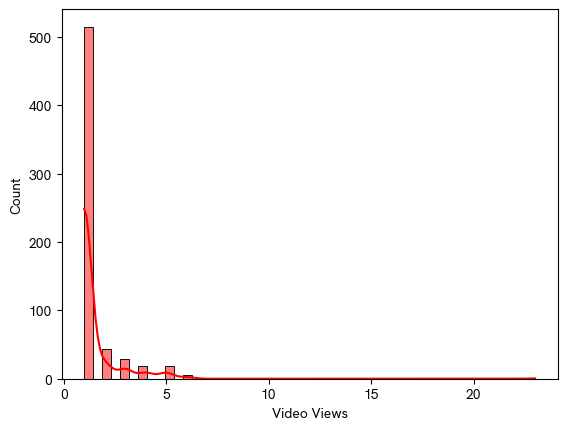

In [558]:

sns.histplot(df.groupby("Creator Name")["Video Views"].count().sort_values(ascending=False), bins=50, kde=True, color=palette[0])

In [559]:
df.columns


Index(['Video Views', 'Video Title', 'Channel URL', 'Creator Name',
       'Creator Gender', 'Total Channel Subcribers', 'Total Chanel Views',
       'Duration of Video', 'Duration in Seconds', 'Date of Video Upload',
       'No of Likes', 'Language of the Video', 'Subtitle', 'Video Description',
       'Hashtags', 'No of Comments', 'Date of the Last Comment',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 'DayOfWeek', 'Friday',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday'],
      dtype='object')

In [560]:
df.groupby("Creator Name")["Video Views"].count().sort_values(ascending=False)

Creator Name
Ganesh Prasad           23
Business Insider         6
Tanmay Singh             6
Zakir Khan               6
Rahul M                  6
                        ..
Gaurav                   1
Gaurav                   1
Gaming Moments           1
GameClips                1
 Anubhav Singh Bassi     1
Name: Video Views, Length: 630, dtype: int64

In [561]:
df.sort_values(by='Date of Video Upload', ascending=True,inplace=True)

In [562]:
mean_cols = ["Video Views", "Duration in Seconds", "No of Likes", "No of Comments", "Hashtags"]
for col in mean_cols:
    df[f"Mean {col} Until Then"] = (
        df.groupby("Channel URL")[col].transform(lambda x: x.expanding().mean())
    )


In [563]:
df = df.sort_values("Date of Video Upload").groupby("Creator Name").tail(1)
df.head()

,Video Views,Video Title,Channel URL,Creator Name,Creator Gender,Total Channel Subcribers,Total Chanel Views,Duration of Video,Duration in Seconds,Date of Video Upload,...,Saturday,Sunday,Thursday,Tuesday,Wednesday,Mean Video Views Until Then,Mean Duration in Seconds Until Then,Mean No of Likes Until Then,Mean No of Comments Until Then,Mean Hashtags Until Then
866,246636162,Me at the zoo,https://www.youtube.com/c/jawed,Jawed,Male,3110000.0,2.448498e+08,00:00:19,19.0,2005-04-24,...,False,True,False,False,False,246636162.0,19.0,12000000.0,11244803.0,0.0
446,19897294,Drug problems,https://www.youtube.com/user/JAM05028,Jam05028,Male,211000.0,3.369131e+07,00:05:07,307.0,2007-10-28,...,False,True,False,False,False,19897294.0,307.0,230000.0,5343.0,0.0
868,1751708,YouTube Captions and Subtitles,https://www.youtube.com/c/youtube,YouTube,NaN,33600000.0,2.772516e+10,00:01:36,96.0,2008-09-22,...,False,False,False,False,False,3029969.0,96.0,15400.0,3226.5,0.0
21,151671688,Seaworld SHAMU Killer Whale Show,https://www.youtube.com/c/videotragic,Videotragic,NaN,405000.0,1.515964e+08,00:09:53,593.0,2009-07-18,...,True,False,False,False,False,151671688.0,593.0,911000.0,32478.0,0.0
14,21274487,Sugino Sensei 10th Dan Master of Katori Shinto...,https://www.youtube.com/c/100healthyears,100 Years Of Health,NaN,25500.0,2.132878e+07,00:04:16,256.0,2010-05-03,...,False,False,False,False,False,21274487.0,256.0,196000.0,16733.0,7.0


In [564]:
df.columns

Index(['Video Views', 'Video Title', 'Channel URL', 'Creator Name',
       'Creator Gender', 'Total Channel Subcribers', 'Total Chanel Views',
       'Duration of Video', 'Duration in Seconds', 'Date of Video Upload',
       'No of Likes', 'Language of the Video', 'Subtitle', 'Video Description',
       'Hashtags', 'No of Comments', 'Date of the Last Comment',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 'DayOfWeek', 'Friday',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday',
       'Mean Video Views Until Then', 'Mean Duration in Seconds Until Then',
       'Mean No of Likes Until Then', 'Mean No of Comments Until Then',
       'Mean Hashtags Until Then'],
      dtype='object')

In [565]:
# Drop specified columns
df.drop(columns=["Video Views", "Duration in Seconds", "No of Likes", "No of Comments", "Hashtags"], inplace=True)

# Rename mean columns
df.rename(columns={
    'Mean Video Views Until Then': 'Mean Video Views',
    'Mean Duration in Seconds Until Then': 'Mean Duration in Seconds',
    'Mean No of Likes Until Then': 'Mean No of Likes',
    'Mean No of Comments Until Then': 'Mean No of Comments',
    'Mean Hashtags Until Then': 'Mean Hashtags'
}, inplace=True)

### Log Transform

In [566]:
import numpy as np

numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

log_numeric_columns = []

for col in numerical_columns:
    df[f'Log {col}'] = np.log(df[col].replace(0, np.nan))
    log_numeric_columns.append(f'Log {col}')

df[log_numeric_columns].head()

,Log Total Channel Subcribers,Log Total Chanel Views,Log Maximum Quality of the Video,Log No of Videos the Channel,Log No of Playlist,Log Premiered or Not,Log Community Engagement (Posts per week),Log Mean Video Views,Log Mean Duration in Seconds,Log Mean No of Likes,Log Mean No of Comments,Log Mean Hashtags
866,14.950133,19.316155,5.480639,0.000000,NaN,NaN,NaN,19.323425,2.944439,16.300417,16.235417,NaN
446,12.259613,17.332751,6.173786,4.382027,1.945910,NaN,NaN,16.806094,5.726848,12.345835,8.583543,NaN
868,17.330037,24.045606,5.886104,6.300786,NaN,NaN,2.890372,14.924063,4.564348,9.642123,8.079153,NaN
21,12.911642,18.836732,6.579251,2.708050,NaN,NaN,NaN,18.837229,6.385194,13.722298,10.388318,NaN
14,10.146434,16.875568,5.480639,5.730100,3.044522,NaN,NaN,16.873019,5.545177,12.185870,9.725138,1.94591


In [567]:
import seaborn as sns
#sns.pairplot(df[log_numeric_columns], diag_kind='kde', markers='o', plot_kws={'alpha': 0.5})

<Axes: >

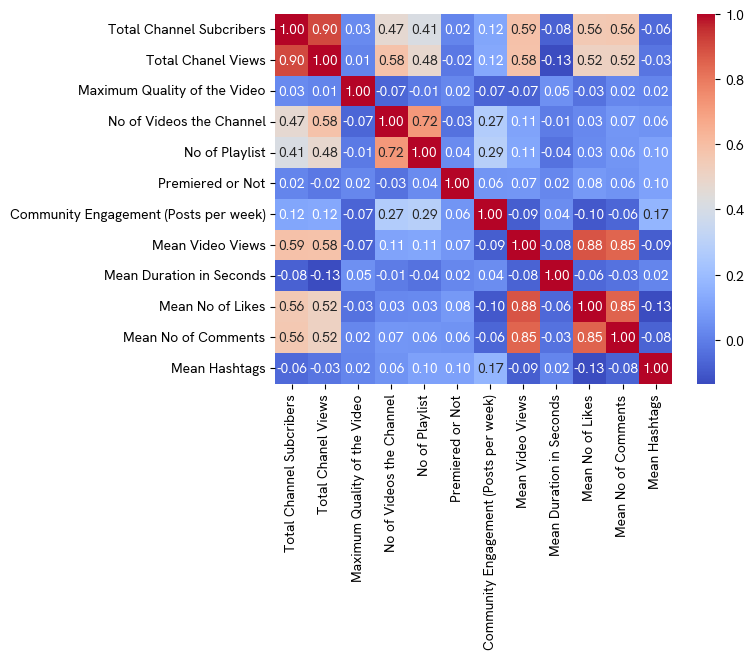

In [568]:
sns.heatmap(df[numerical_columns].corr("spearman"), annot=True, cmap='coolwarm', fmt='.2f')

In [569]:
df.columns

Index(['Video Title', 'Channel URL', 'Creator Name', 'Creator Gender',
       'Total Channel Subcribers', 'Total Chanel Views', 'Duration of Video',
       'Date of Video Upload', 'Language of the Video', 'Subtitle',
       'Video Description', 'Date of the Last Comment',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 'DayOfWeek', 'Friday',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday',
       'Mean Video Views', 'Mean Duration in Seconds', 'Mean No of Likes',
       'Mean No of Comments', 'Mean Hashtags', 'Log Total Channel Subcribers',
       'Log Total Chanel Views', 'Log Maximum Quality of the Video',
       'Log No of Videos the Channel', 'Log No of Playlist',
       'Log Premiered or Not', 'Log Community Engagement (Posts per week)',
       'Log Mean Video Views', 'Log Mean Duration in Seconds',
       'Log Mean No of Likes', 'Log Mean No of

### Marketing Cost Analysis

In [570]:
# İstenen aralık
a, b = 0, 8

# Grup ortalamalarını bul
group_means = df.groupby("Creator Name")["Log Mean Video Views"].transform("mean")

# Min-Max Scaling
scaled_means = a + (group_means - group_means.min()) * (b - a) / (group_means.max() - group_means.min())

# Yeni sütun olarak ekle
df["CPM"] = scaled_means


In [571]:
# İstenen aralık
a, b = 0, 1

# Grup ortalamalarını bul
group_means = df.groupby("Creator Name")["Log Total Channel Subcribers"].transform("mean")

# Min-Max Scaling
scaled_means = a + (group_means - group_means.min()) * (b - a) / (group_means.max() - group_means.min())

# Yeni sütun olarak ekle
df["Sub Bonus"] = scaled_means


In [572]:
df["CPM_Enhanced"] = df["CPM"] + df["Sub Bonus"]
df["Marketing Cost"] = df["CPM_Enhanced"] * df["Mean Video Views"]



### Bucketing by Log of Video Views

In [573]:
# First, we need to calculate our IQR.
q1 = df["Log Mean Video Views"].quantile(0.25)                 
q3 = df["Log Mean Video Views"].quantile(0.75)
iqr = q3 - q1

# Now let's calculate upper and lower bounds.
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

# Let us create our bins:
num_bins = 6
bin_width = (upper - lower) / num_bins
bins = [lower + i*bin_width for i in range(num_bins)]
bins += [upper, float('inf')]  # Now we add our last bin, which will contain any value greater than the upper-bound of the IQR.

# Let us create our labels:
labels = [f'Bucket {i}' for i in range(1,num_bins+1)]
labels.append('Outside IQR')

# Finally, we add a new column to the df:
df['Buckets'] = pd.cut(df["Log Mean Video Views"], bins=bins, labels=labels)
df[["Log Mean Video Views",'Buckets']]


,Log Mean Video Views,Buckets
866,19.323425,Bucket 5
446,16.806094,Bucket 4
868,14.924063,Bucket 4
21,18.837229,Bucket 5
14,16.873019,Bucket 5
...,...,...
111,13.207858,Bucket 3
493,14.760420,Bucket 4
248,12.779078,Bucket 3
434,16.012422,Bucket 4


In [574]:
df.groupby('Buckets').size()

/var/folders/6j/1nsywzcs1v5_6gn_3972hssr0000gn/T/ipykernel_80887/2328947734.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Buckets').size()


Buckets
Bucket 1        20
Bucket 2        97
Bucket 3       193
Bucket 4       210
Bucket 5        86
Bucket 6        16
Outside IQR      2
dtype: int64

#### Removing Outliers for Each Bucket

In [575]:
numeric_cols = ['Mean Video Views', 'Marketing Cost', 'Mean No of Likes', 'Mean No of Comments']


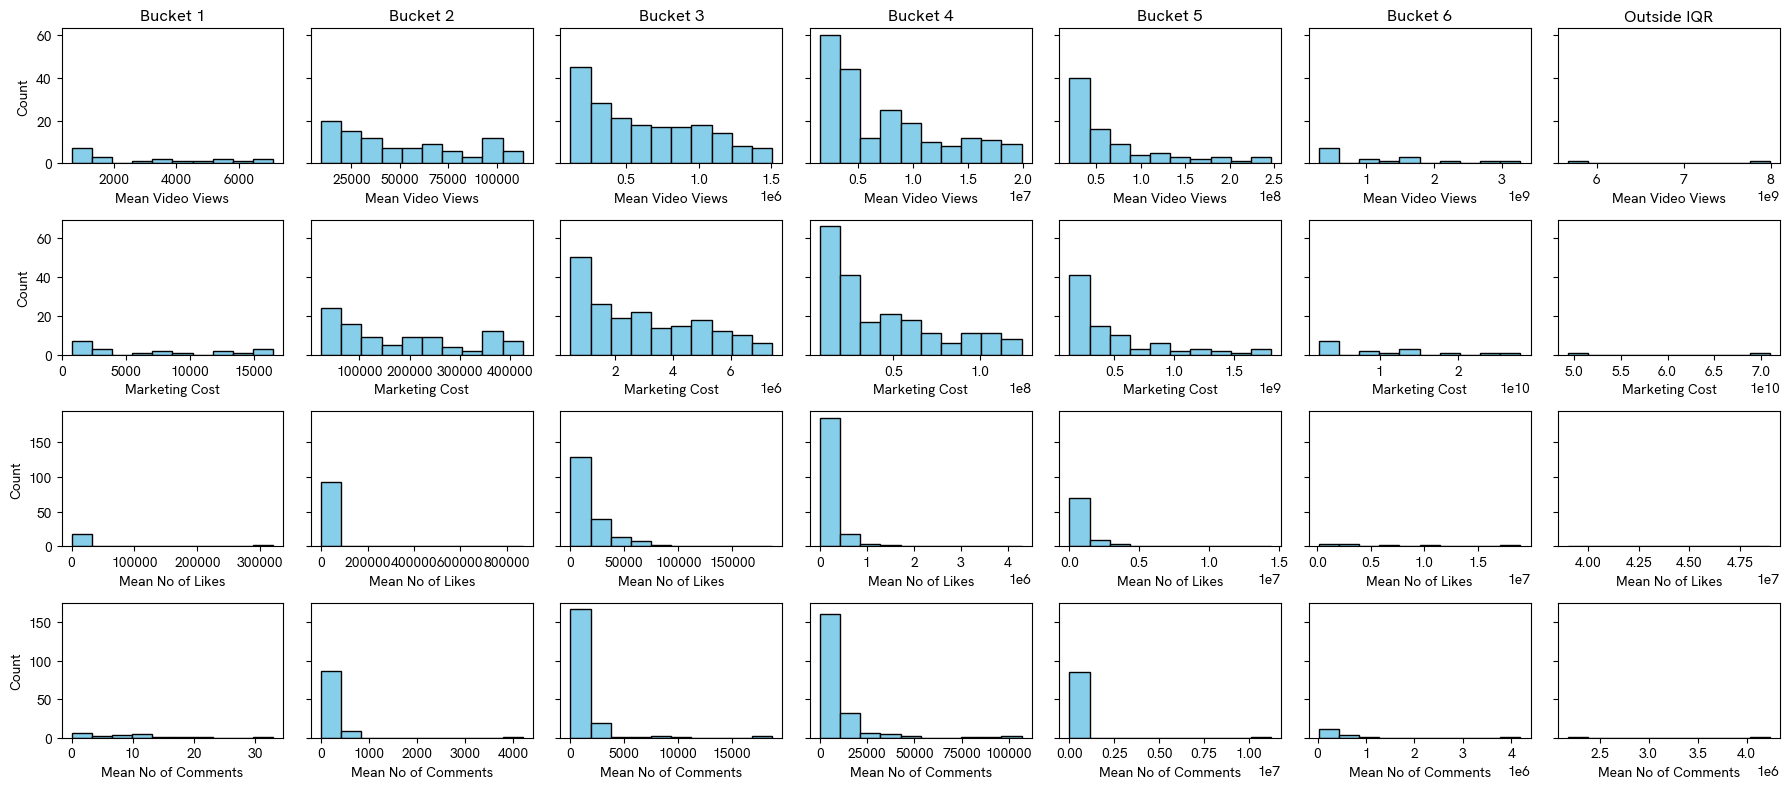

In [576]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(numeric_cols), len(labels), figsize=(18, 8), sharey='row')
for row, col_name in enumerate(numeric_cols):
    for col, label in enumerate(labels):
        ax = axes[row, col]
        subset = df[df['Buckets'] == label][col_name]
        ax.hist(subset, bins=10, color='skyblue', edgecolor='black')
        ax.set_title(label if row == 0 else "")
        ax.set_xlabel(col_name)
        if col == 0:
            ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [577]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# Define custom IQR coefficients for each column
iqr_coeffs = {
    'Mean Video Views': 1.8,
    'Marketing Cost': 1.8,
    'Mean No of Likes': 3,
    'Mean No of Comments': 3.1
}

# Function to remove outliers by IQR for each group with custom coefficients
def remove_outliers_iqr(df_group):
    for col in numeric_cols:
        Q1 = df_group[col].quantile(0.25)
        Q3 = df_group[col].quantile(0.75)
        IQR = Q3 - Q1
        coeff = iqr_coeffs.get(col, 1.8)
        lower_bound = Q1 - coeff * IQR
        upper_bound = Q3 + coeff * IQR
        df_group = df_group[(df_group[col] >= lower_bound) & (df_group[col] <= upper_bound)]
    return df_group

# Apply group-wise outlier removal
df = df.groupby("Buckets").apply(remove_outliers_iqr).reset_index(drop=True)



/var/folders/6j/1nsywzcs1v5_6gn_3972hssr0000gn/T/ipykernel_80887/4135239955.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby("Buckets").apply(remove_outliers_iqr).reset_index(drop=True)
/var/folders/6j/1nsywzcs1v5_6gn_3972hssr0000gn/T/ipykernel_80887/4135239955.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Buckets").apply(remove_outliers_iqr).reset_index(drop=True)


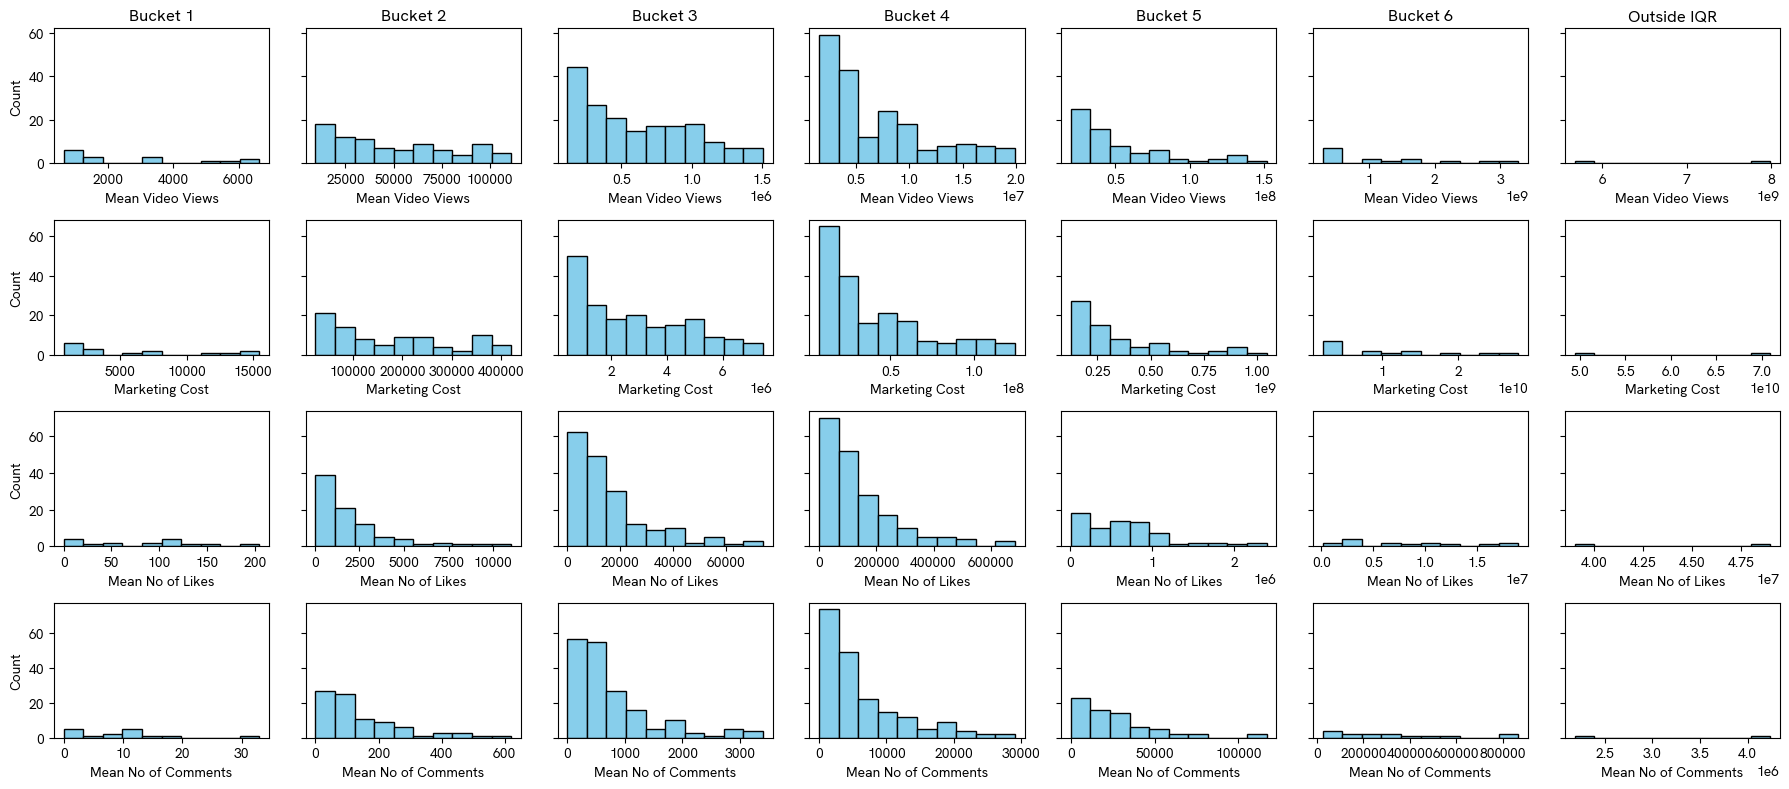

In [578]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(numeric_cols), len(labels), figsize=(18, 8), sharey='row')
for row, col_name in enumerate(numeric_cols):
    for col, label in enumerate(labels):
        ax = axes[row, col]
        subset = df[df['Buckets'] == label][col_name]
        ax.hist(subset, bins=10, color='skyblue', edgecolor='black')
        ax.set_title(label if row == 0 else "")
        ax.set_xlabel(col_name)
        if col == 0:
            ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### Bucket Analysis

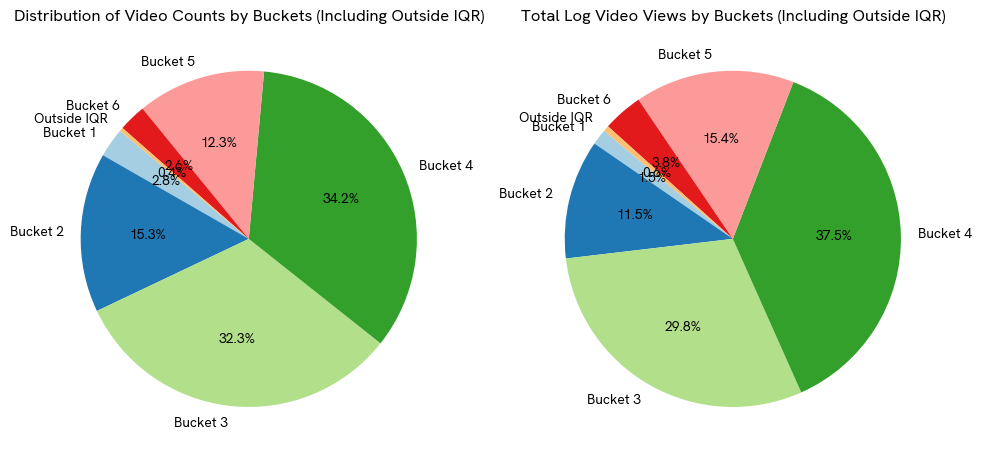

In [579]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

bucket_counts = df.groupby('Buckets',observed=True)['Log Mean Video Views'].count().reindex(labels).copy()
bucket_sums = df.groupby('Buckets',observed=True)['Log Mean Video Views'].sum().reindex(labels).copy()

# Pie chart for bucket counts
axes[0].pie(bucket_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
axes[0].set_title('Distribution of Video Counts by Buckets (Including Outside IQR)')

# Pie chart for bucket sums
axes[1].pie(bucket_sums, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
axes[1].set_title('Total Log Video Views by Buckets (Including Outside IQR)')

plt.tight_layout()
plt.show()

In [580]:
test_data = df[df["Buckets"] != "Outside IQR"].dropna(subset=["Buckets"]).copy()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 565 entries, 0 to 564
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Video Title                                565 non-null    object        
 1   Channel URL                                565 non-null    object        
 2   Creator Name                               565 non-null    object        
 3   Creator Gender                             366 non-null    object        
 4   Total Channel Subcribers                   565 non-null    float64       
 5   Total Chanel Views                         557 non-null    float64       
 6   Duration of Video                          565 non-null    object        
 7   Date of Video Upload                       565 non-null    datetime64[ns]
 8   Language of the Video                      553 non-null    object        
 9   Subtitle                  

In [581]:
bucket_names = ['Bucket 1', 'Bucket 2', 'Bucket 3', 'Bucket 4', 'Bucket 5', 'Bucket 6']


### Determining the Best Bucket

In [582]:
"Buckets" and numeric_cols

['Mean Video Views',
 'Marketing Cost',
 'Mean No of Likes',
 'Mean No of Comments']

In [583]:
test_data.columns

Index(['Video Title', 'Channel URL', 'Creator Name', 'Creator Gender',
       'Total Channel Subcribers', 'Total Chanel Views', 'Duration of Video',
       'Date of Video Upload', 'Language of the Video', 'Subtitle',
       'Video Description', 'Date of the Last Comment',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 'DayOfWeek', 'Friday',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday',
       'Mean Video Views', 'Mean Duration in Seconds', 'Mean No of Likes',
       'Mean No of Comments', 'Mean Hashtags', 'Log Total Channel Subcribers',
       'Log Total Chanel Views', 'Log Maximum Quality of the Video',
       'Log No of Videos the Channel', 'Log No of Playlist',
       'Log Premiered or Not', 'Log Community Engagement (Posts per week)',
       'Log Mean Video Views', 'Log Mean Duration in Seconds',
       'Log Mean No of Likes', 'Log Mean No of

In [584]:
bucket_analysis = test_data[["Mean Video Views", "Marketing Cost", "Mean No of Likes", "Mean No of Comments","Buckets"]].copy().dropna()
bucket_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 565 entries, 0 to 564
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Mean Video Views     565 non-null    float64 
 1   Marketing Cost       565 non-null    float64 
 2   Mean No of Likes     565 non-null    float64 
 3   Mean No of Comments  565 non-null    float64 
 4   Buckets              565 non-null    category
dtypes: category(1), float64(4)
memory usage: 23.0 KB


In [585]:
# Scale numeric columns after outlier removal


scaler = MinMaxScaler(feature_range=(0, 1_000_000))
scaled_values = scaler.fit_transform(bucket_analysis[numeric_cols])

bucket_analysis[numeric_cols] = scaled_values

bucket_analysis.describe()

,Mean Video Views,Marketing Cost,Mean No of Likes,Mean No of Comments
count,565.000000,565.000000,565.000000,565.000000
mean,12349.481845,11282.405445,18653.002745,16325.134472
std,74467.601857,72881.079819,85988.690774,77748.837375
min,0.000000,0.000000,0.000000,0.000000
25%,70.557507,34.476069,289.473684,273.253025
50%,452.608773,255.470820,1421.052632,1268.262987
75%,2697.508424,1825.466136,7947.368421,6729.864596
max,1000000.000000,1000000.000000,1000000.000000,1000000.000000


#### Understanding Bucket Characteristics

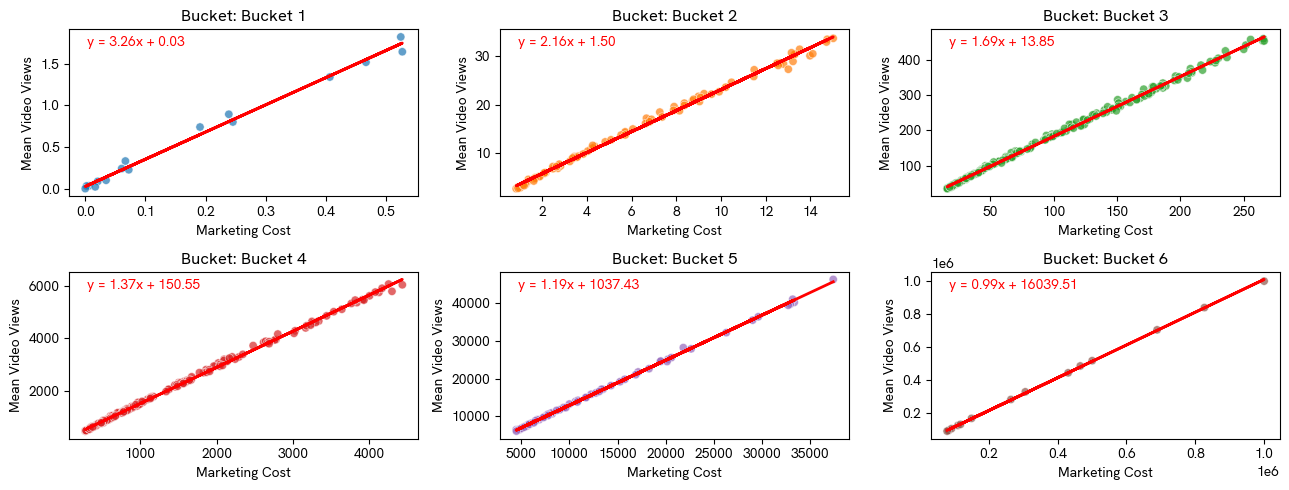

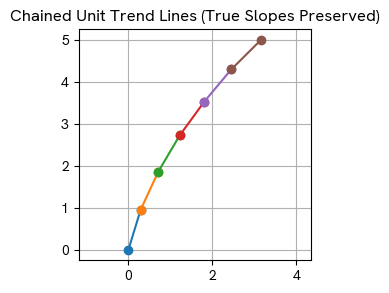

In [586]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

buckets = ['Bucket 1', 'Bucket 2', 'Bucket 3', 'Bucket 4', 'Bucket 5', 'Bucket 6']

# Part 1: Separate scatter plots with trend lines and equations
fig, axes = plt.subplots(2, 3, figsize=(13, 5))
axes = axes.flatten()

slopes = []
intercepts = []

for i, bucket in enumerate(buckets):
    subset = bucket_analysis[bucket_analysis["Buckets"] == bucket]
    
    # Scatter plot
    sns.scatterplot(
        data=subset,
        x="Marketing Cost",
        y="Mean Video Views",
        hue="Buckets",
        alpha=0.7,
        ax=axes[i],
        legend=False
    )
    
    # Fit linear regression for the bucket
    x = subset["Marketing Cost"].values
    y = subset["Mean Video Views"].values
    if len(x) > 1:  # Avoid fitting if only one point
        slope, intercept = np.polyfit(x, y, 1)
        slopes.append(slope)
        intercepts.append(intercept)
        
        # Trend line
        axes[i].plot(x, slope * x + intercept, color="red", linewidth=2)
        
        # Equation text
        eq_text = f"y = {slope:.2f}x + {intercept:.2f}"
        axes[i].text(0.05, 0.9, eq_text, transform=axes[i].transAxes, 
                     fontsize=10, color="red", fontweight="bold")
    else:
        # For buckets with one or zero points, store NaN for slope/intercept
        slopes.append(np.nan)
        intercepts.append(np.nan)

    axes[i].set_title(f"Bucket: {bucket}")
    axes[i].set_xlabel("Marketing Cost")
    axes[i].set_ylabel("Mean Video Views")

plt.tight_layout()
plt.show()

# Part 2: Chained unit trend lines plot

# Convert slopes to unit vectors (skip NaNs)
directions = []
valid_buckets = []
valid_slopes = []
valid_intercepts = []

for slope, intercept, bucket in zip(slopes, intercepts, buckets):
    if not np.isnan(slope):
        vec = np.array([1, slope])
        vec = vec / np.linalg.norm(vec)
        directions.append(vec)
        valid_buckets.append(bucket)
        valid_slopes.append(slope)
        valid_intercepts.append(intercept)

# Chain them end-to-end
points = [(0, 0)]
for vec in directions:
    last_point = np.array(points[-1])
    new_point = last_point + vec
    points.append(tuple(new_point))

# Plot chained unit lines
points = np.array(points)
plt.figure(figsize=(3, 3))
for i, bucket in enumerate(valid_buckets):
    plt.plot(points[i:i+2, 0], points[i:i+2, 1], marker="o",
             label=f"{bucket} | y={valid_slopes[i]:.2f}x + {valid_intercepts[i]:.2f}")

plt.axis("equal")
plt.title("Chained Unit Trend Lines (True Slopes Preserved)")
plt.grid(True)
plt.show()


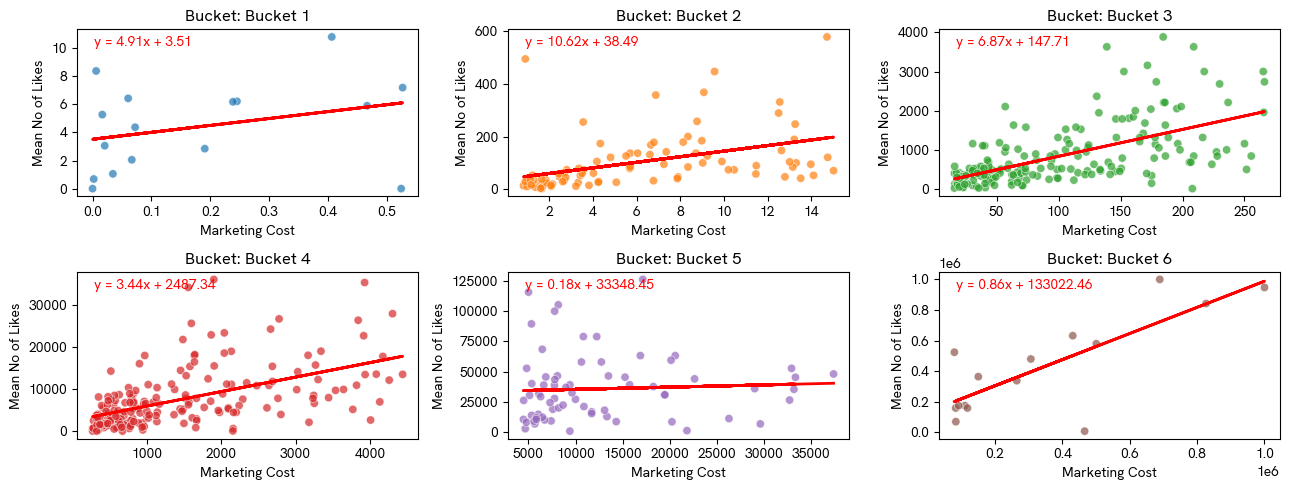

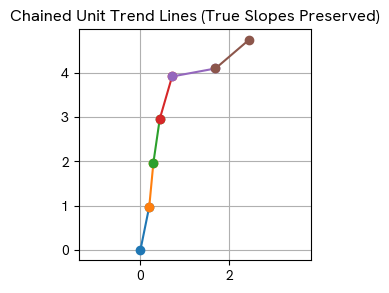

In [587]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

buckets = ['Bucket 1', 'Bucket 2', 'Bucket 3', 'Bucket 4', 'Bucket 5', 'Bucket 6']

# Part 1: Separate scatter plots with trend lines and equations
fig, axes = plt.subplots(2, 3, figsize=(13, 5))
axes = axes.flatten()

slopes = []
intercepts = []

for i, bucket in enumerate(buckets):
    subset = bucket_analysis[bucket_analysis["Buckets"] == bucket]
    
    # Scatter plot
    sns.scatterplot(
        data=subset,
        x="Marketing Cost",
        y="Mean No of Likes",
        hue="Buckets",
        alpha=0.7,
        ax=axes[i],
        legend=False
    )
    
    # Fit linear regression for the bucket
    x = subset["Marketing Cost"].values
    y = subset["Mean No of Likes"].values
    if len(x) > 1:  # Avoid fitting if only one point
        slope, intercept = np.polyfit(x, y, 1)
        slopes.append(slope)
        intercepts.append(intercept)
        
        # Trend line
        axes[i].plot(x, slope * x + intercept, color="red", linewidth=2)
        
        # Equation text
        eq_text = f"y = {slope:.2f}x + {intercept:.2f}"
        axes[i].text(0.05, 0.9, eq_text, transform=axes[i].transAxes, 
                     fontsize=10, color="red", fontweight="bold")
    else:
        # For buckets with one or zero points, store NaN for slope/intercept
        slopes.append(np.nan)
        intercepts.append(np.nan)

    axes[i].set_title(f"Bucket: {bucket}")
    axes[i].set_xlabel("Marketing Cost")
    axes[i].set_ylabel("Mean No of Likes")

plt.tight_layout()
plt.show()

# Part 2: Chained unit trend lines plot

# Convert slopes to unit vectors (skip NaNs)
directions = []
valid_buckets = []
valid_slopes = []
valid_intercepts = []

for slope, intercept, bucket in zip(slopes, intercepts, buckets):
    if not np.isnan(slope):
        vec = np.array([1, slope])
        vec = vec / np.linalg.norm(vec)
        directions.append(vec)
        valid_buckets.append(bucket)
        valid_slopes.append(slope)
        valid_intercepts.append(intercept)

# Chain them end-to-end
points = [(0, 0)]
for vec in directions:
    last_point = np.array(points[-1])
    new_point = last_point + vec
    points.append(tuple(new_point))

# Plot chained unit lines
points = np.array(points)
plt.figure(figsize=(3, 3))
for i, bucket in enumerate(valid_buckets):
    plt.plot(points[i:i+2, 0], points[i:i+2, 1], marker="o",
             label=f"{bucket} | y={valid_slopes[i]:.2f}x + {valid_intercepts[i]:.2f}")

plt.axis("equal")
plt.title("Chained Unit Trend Lines (True Slopes Preserved)")
plt.grid(True)
plt.show()


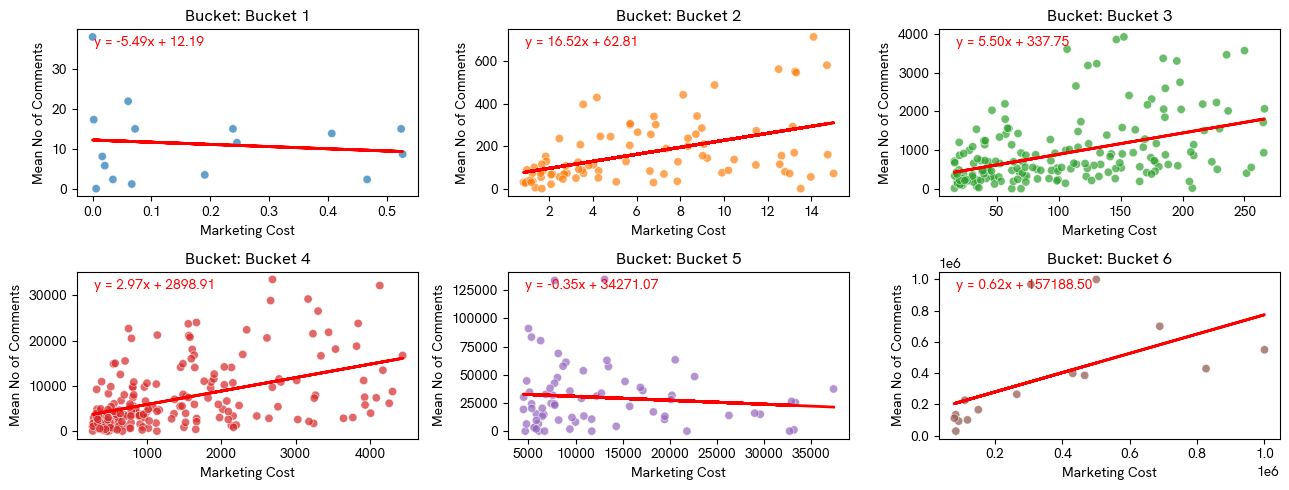

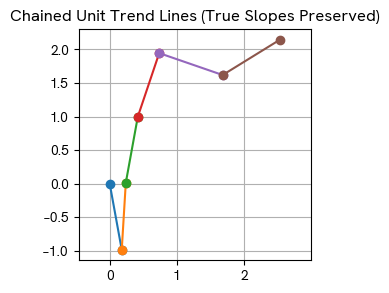

In [588]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

buckets = ['Bucket 1', 'Bucket 2', 'Bucket 3', 'Bucket 4', 'Bucket 5', 'Bucket 6']

# Part 1: Separate scatter plots with trend lines and equations
fig, axes = plt.subplots(2, 3, figsize=(13, 5))
axes = axes.flatten()

slopes = []
intercepts = []

for i, bucket in enumerate(buckets):
    subset = bucket_analysis[bucket_analysis["Buckets"] == bucket]
    
    # Scatter plot
    sns.scatterplot(
        data=subset,
        x="Marketing Cost",
        y="Mean No of Comments",
        hue="Buckets",
        alpha=0.7,
        ax=axes[i],
        legend=False
    )
    
    # Fit linear regression for the bucket
    x = subset["Marketing Cost"].values
    y = subset["Mean No of Comments"].values
    if len(x) > 1:  # Avoid fitting if only one point
        slope, intercept = np.polyfit(x, y, 1)
        slopes.append(slope)
        intercepts.append(intercept)
        
        # Trend line
        axes[i].plot(x, slope * x + intercept, color="red", linewidth=2)
        
        # Equation text
        eq_text = f"y = {slope:.2f}x + {intercept:.2f}"
        axes[i].text(0.05, 0.9, eq_text, transform=axes[i].transAxes, 
                     fontsize=10, color="red", fontweight="bold")
    else:
        # For buckets with one or zero points, store NaN for slope/intercept
        slopes.append(np.nan)
        intercepts.append(np.nan)

    axes[i].set_title(f"Bucket: {bucket}")
    axes[i].set_xlabel("Marketing Cost")
    axes[i].set_ylabel("Mean No of Comments")

plt.tight_layout()
plt.show()

# Part 2: Chained unit trend lines plot

# Convert slopes to unit vectors (skip NaNs)
directions = []
valid_buckets = []
valid_slopes = []
valid_intercepts = []

for slope, intercept, bucket in zip(slopes, intercepts, buckets):
    if not np.isnan(slope):
        vec = np.array([1, slope])
        vec = vec / np.linalg.norm(vec)
        directions.append(vec)
        valid_buckets.append(bucket)
        valid_slopes.append(slope)
        valid_intercepts.append(intercept)

# Chain them end-to-end
points = [(0, 0)]
for vec in directions:
    last_point = np.array(points[-1])
    new_point = last_point + vec
    points.append(tuple(new_point))

# Plot chained unit lines
points = np.array(points)
plt.figure(figsize=(3, 3))
for i, bucket in enumerate(valid_buckets):
    plt.plot(points[i:i+2, 0], points[i:i+2, 1], marker="o",
             label=f"{bucket} | y={valid_slopes[i]:.2f}x + {valid_intercepts[i]:.2f}")

plt.axis("equal")
plt.title("Chained Unit Trend Lines (True Slopes Preserved)")
plt.grid(True)
plt.show()


küme 4 etkileşim açısından öğimin düzleşmeyue bşalamdıın son küme olarak en verimli kümelerden biri bu yüzden alışamya aldık açıkcası 5. küme hem verim açısından bizi tam düşürmüyor hem de model eğitimi için eldeki veri dengesini koruyor  4 ve 5. kümeleri seçme sebebimiz buydu

### Feature Creation

#### Like and Comment Score

In [589]:
df.rename(columns={col: col.replace('Mean ', '') for col in df.columns if 'Mean ' in col}, inplace=True)
df.columns

Index(['Video Title', 'Channel URL', 'Creator Name', 'Creator Gender',
       'Total Channel Subcribers', 'Total Chanel Views', 'Duration of Video',
       'Date of Video Upload', 'Language of the Video', 'Subtitle',
       'Video Description', 'Date of the Last Comment',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 'DayOfWeek', 'Friday',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday',
       'Video Views', 'Duration in Seconds', 'No of Likes', 'No of Comments',
       'Hashtags', 'Log Total Channel Subcribers', 'Log Total Chanel Views',
       'Log Maximum Quality of the Video', 'Log No of Videos the Channel',
       'Log No of Playlist', 'Log Premiered or Not',
       'Log Community Engagement (Posts per week)', 'Log Video Views',
       'Log Duration in Seconds', 'Log No of Likes', 'Log No of Comments',
       'Log Hashtags', 'CPM', 'Sub Bonus

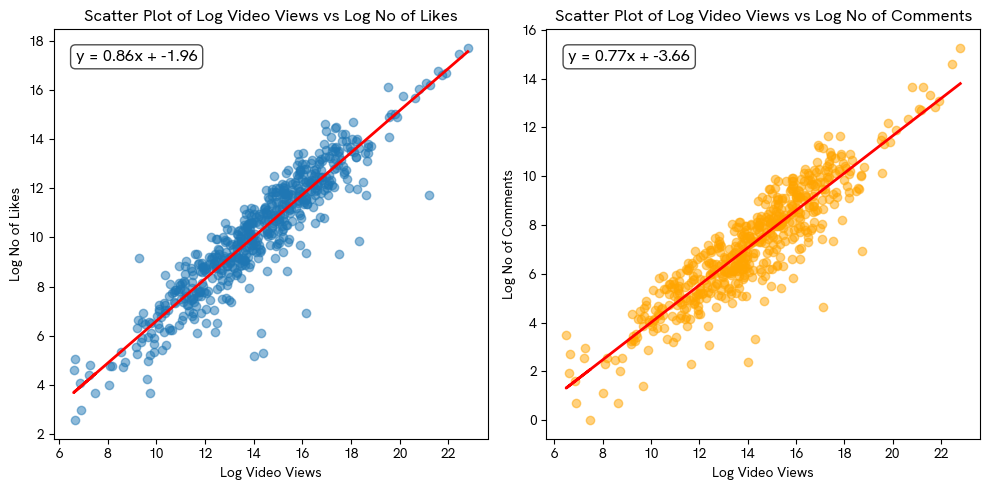

In [590]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Scatter plot: Log Video Views vs Log No of Likes
axs[0].scatter(df['Log Video Views'], df['Log No of Likes'], alpha=0.5)
axs[0].set_xlabel('Log Video Views')
axs[0].set_ylabel('Log No of Likes')
axs[0].set_title('Scatter Plot of Log Video Views vs Log No of Likes')

# Add trend line
mask0 = df['Log Video Views'].notnull() & df['Log No of Likes'].notnull()
x = df.loc[mask0, 'Log Video Views']
y = df.loc[mask0, 'Log No of Likes']
A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
axs[0].plot(x, m*x + c, color='red', linewidth=2)
# Show formula on the plot
axs[0].text(
    0.05, 0.95,
    f'y = {m:.2f}x + {c:.2f}',
    transform=axs[0].transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

# Scatter plot: Log Video Views vs Log No of Comments
axs[1].scatter(df['Log Video Views'], df['Log No of Comments'], alpha=0.5, color='orange')
axs[1].set_xlabel('Log Video Views')
axs[1].set_ylabel('Log No of Comments')
axs[1].set_title('Scatter Plot of Log Video Views vs Log No of Comments')

# Add trend line
mask1 = df['Log Video Views'].notnull() & df['Log No of Comments'].notnull()
x = df.loc[mask1, 'Log Video Views']
y = df.loc[mask1, 'Log No of Comments']
A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
axs[1].plot(x, m*x + c, color='red', linewidth=2)
# Show formula on the plot
axs[1].text(
    0.05, 0.95,
    f'y = {m:.2f}x + {c:.2f}',
    transform=axs[1].transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)


plt.tight_layout()
plt.show()

In [591]:
df['Like Score'] = df['Log No of Likes'] / df['Log Video Views']
df['Comment Score'] = df['Log No of Comments'] / df['Log Video Views']



#### Duration Analysis

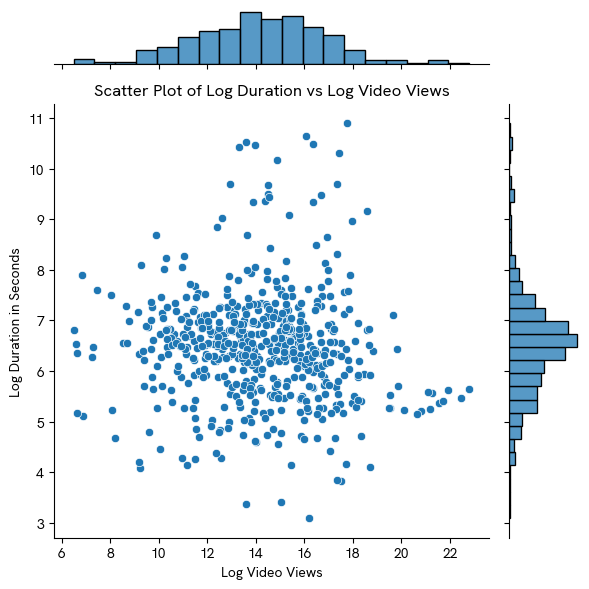

In [592]:
import matplotlib.pyplot as plt

sns.jointplot(data=df, x="Log Video Views", y="Log Duration in Seconds")

plt.ylabel('Log Duration in Seconds')
plt.xlabel('Log Video Views')
plt.title('Scatter Plot of Log Duration vs Log Video Views')



plt.tight_layout()
plt.show()

#### Community Engagement Analysis

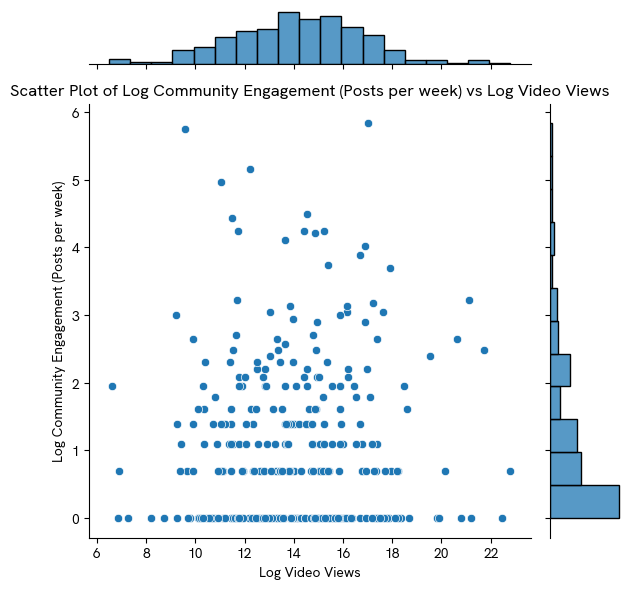

In [593]:
import matplotlib.pyplot as plt

sns.jointplot(data=df, x="Log Video Views", y="Log Community Engagement (Posts per week)")

plt.ylabel('Log Community Engagement (Posts per week)')
plt.xlabel('Log Video Views')
plt.title('Scatter Plot of Log Community Engagement (Posts per week) vs Log Video Views')



plt.tight_layout()
plt.show()

#### Loyalty Score ??????

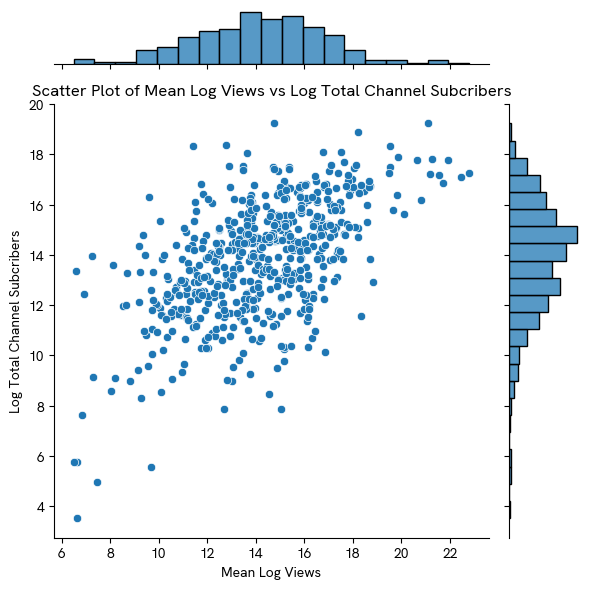

In [594]:
sns.jointplot(data=df, x="Log Video Views", y="Log Total Channel Subcribers")

plt.ylabel('Log Total Channel Subcribers')
plt.xlabel('Mean Log Views')
plt.title('Scatter Plot of Mean Log Views vs Log Total Channel Subcribers')



plt.tight_layout()
plt.show()

<Axes: xlabel='Loyalty Score', ylabel='Count'>

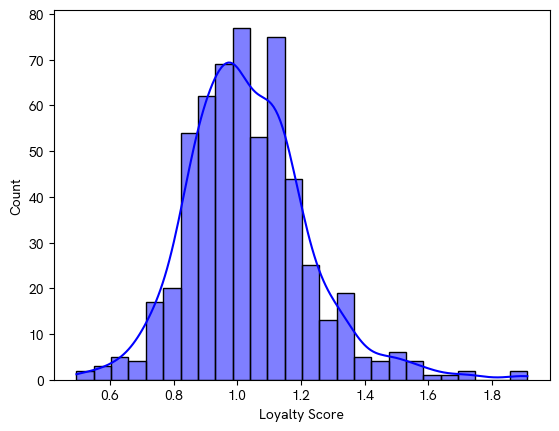

In [595]:
df["Loyalty Score"] =  df["Log Video Views"] / df["Log Total Channel Subcribers"] 

sns.histplot(data=df, x="Loyalty Score", kde=True, color='blue')

#### Atractness Score

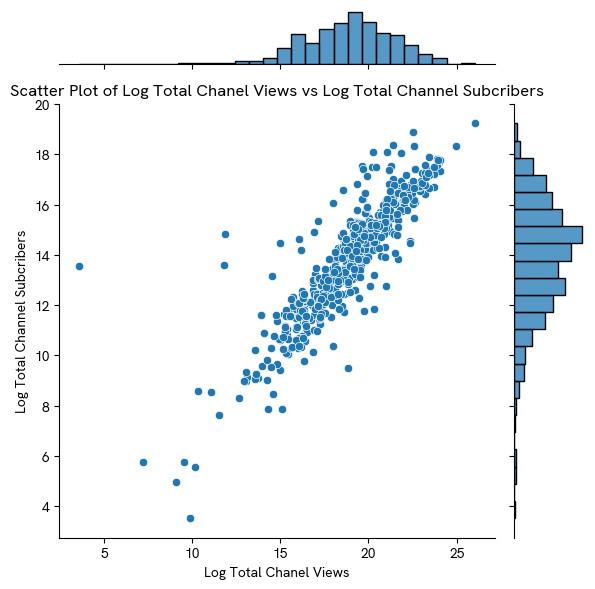

In [596]:
sns.jointplot(data=df, x="Log Total Chanel Views", y="Log Total Channel Subcribers")

plt.xlabel('Log Total Chanel Views')
plt.ylabel('Log Total Channel Subcribers')
plt.title('Scatter Plot of Log Total Chanel Views vs Log Total Channel Subcribers')



plt.tight_layout()
plt.show()

<Axes: xlabel='Atractness Score', ylabel='Count'>

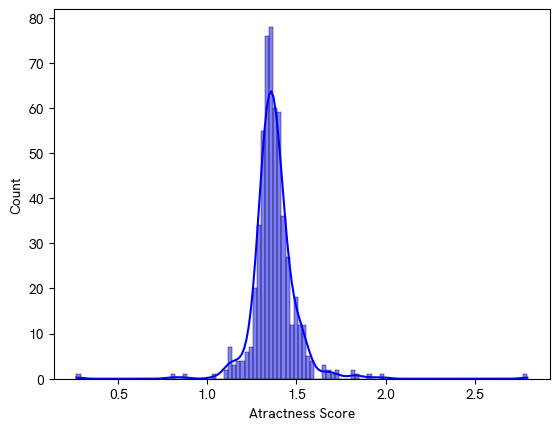

In [597]:
df["Atractness Score"] =  df["Log Total Chanel Views"] / df["Log Total Channel Subcribers"] 

sns.histplot(data=df, x="Atractness Score", kde=True, color='blue')

#### Efficiency Score

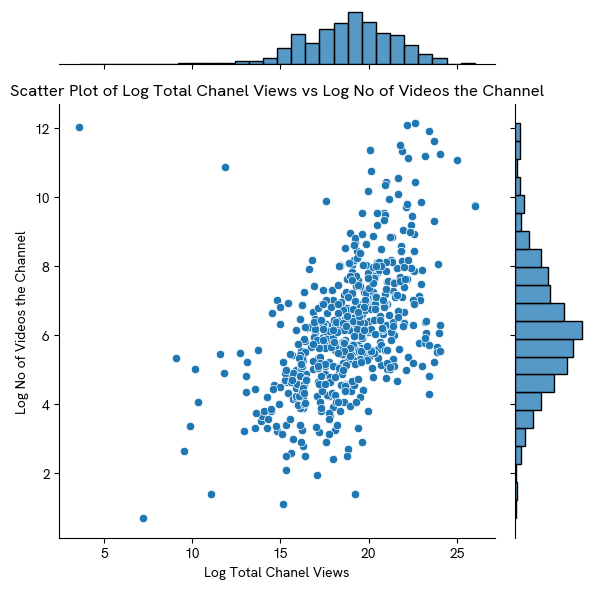

In [598]:
sns.jointplot(data=df, x="Log Total Chanel Views", y="Log No of Videos the Channel")

plt.xlabel('Log Total Chanel Views')
plt.ylabel('Log No of Videos the Channel')
plt.title('Scatter Plot of Log Total Chanel Views vs Log No of Videos the Channel')

plt.tight_layout()
plt.show()

<Axes: xlabel='Efficiency Score', ylabel='Count'>

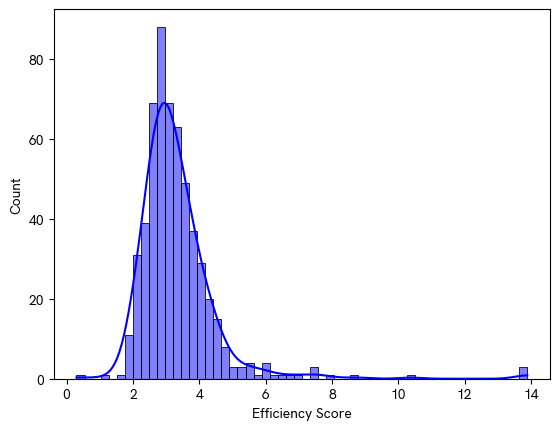

In [599]:
df["Efficiency Score"] =  df["Log Total Chanel Views"] / df["Log No of Videos the Channel"] 

sns.histplot(data=df, x="Efficiency Score", kde=True, color='blue')

In [600]:
df[["Creator Name","Efficiency Score"]].sort_values(by="Efficiency Score", ascending=False).head(10)

,Creator Name,Efficiency Score
535,Anubhav Singh Bassi,13.886011
507,Anubhav Singh Bassi,13.885159
291,Blockshelf,13.784393
1,Udyansh Society,10.369597
476,Court Room,8.764751
51,America Chowrasta FinTech,7.965034
495,Steve Cutts,7.554919
365,Varun Grover,7.493355
86,Rob Hamilton,7.352156
480,Videotragic,6.955828


#### Sub Per Video

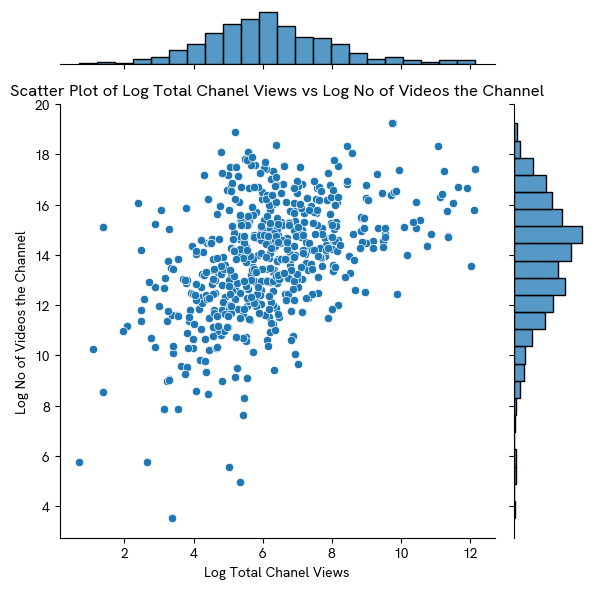

In [601]:
sns.jointplot(data=df, x="Log No of Videos the Channel", y="Log Total Channel Subcribers")

plt.xlabel('Log Total Chanel Views')
plt.ylabel('Log No of Videos the Channel')
plt.title('Scatter Plot of Log Total Chanel Views vs Log No of Videos the Channel')

plt.tight_layout()
plt.show()

<Axes: xlabel='Sub Per Video', ylabel='Count'>

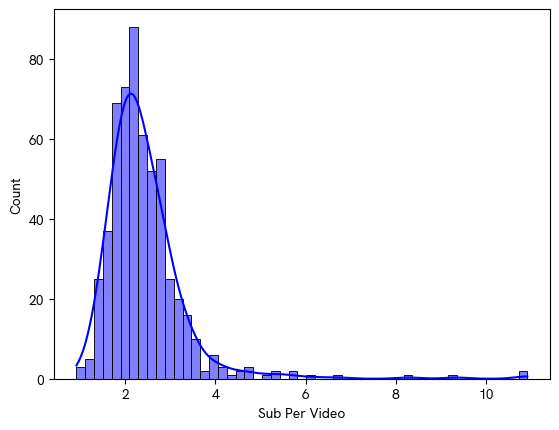

In [602]:
df["Sub Per Video"] =  df["Log Total Channel Subcribers"] / df["Log No of Videos the Channel"] 

sns.histplot(data=df, x="Sub Per Video", kde=True, color='blue')

In [603]:
df[["Creator Name","Sub Per Video"]].sort_values(by="Sub Per Video", ascending=False).head(10)

,Creator Name,Sub Per Video
507,Anubhav Singh Bassi,10.911494
535,Anubhav Singh Bassi,10.911494
291,Blockshelf,9.340112
1,Udyansh Society,8.285402
365,Varun Grover,6.700816
51,America Chowrasta FinTech,6.174917
495,Steve Cutts,5.717540
476,Court Room,5.638308
86,Rob Hamilton,5.363646
509,Abhishek Upmanyu,5.270529


## Exporting the Data

In [604]:
df.columns

Index(['Video Title', 'Channel URL', 'Creator Name', 'Creator Gender',
       'Total Channel Subcribers', 'Total Chanel Views', 'Duration of Video',
       'Date of Video Upload', 'Language of the Video', 'Subtitle',
       'Video Description', 'Date of the Last Comment',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 'DayOfWeek', 'Friday',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday',
       'Video Views', 'Duration in Seconds', 'No of Likes', 'No of Comments',
       'Hashtags', 'Log Total Channel Subcribers', 'Log Total Chanel Views',
       'Log Maximum Quality of the Video', 'Log No of Videos the Channel',
       'Log No of Playlist', 'Log Premiered or Not',
       'Log Community Engagement (Posts per week)', 'Log Video Views',
       'Log Duration in Seconds', 'Log No of Likes', 'Log No of Comments',
       'Log Hashtags', 'CPM', 'Sub Bonus

In [ ]:
df [[
      'Total Channel Subcribers', 'Total Chanel Views',
       'Language of the Video', 'Subtitle',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 
       'Video Views', 'Duration in Seconds', 'No of Likes', 'No of Comments',
       'Hashtags', 'Log Total Channel Subcribers', 'Log Total Chanel Views',
       'Log Maximum Quality of the Video', 'Log No of Videos the Channel',
       'Log No of Playlist', 'Log Premiered or Not',
       'Log Community Engagement (Posts per week)', 'Log Video Views',
       'Log Duration in Seconds', 'Log No of Likes', 'Log No of Comments',
       'Log Hashtags','Marketing Cost',
       'Buckets', 'Like Score', 'Comment Score', 'Loyalty Score',
       'Atractness Score', 'Efficiency Score', 'Sub Per Video']]

,Total Channel Subcribers,Total Chanel Views,Language of the Video,Subtitle,Maximum Quality of the Video,No of Videos the Channel,No of Playlist,Premiered or Not,Community Engagement (Posts per week),Video Views,...,Log No of Comments,Log Hashtags,Marketing Cost,Buckets,Like Score,Comment Score,Loyalty Score,Atractness Score,Efficiency Score,Sub Per Video
0,141.0,8.941000e+03,Malayalam,No,720,207,1.0,0,0,1.747000e+03,...,0.000000,1.098612,2.610766e+03,Bucket 1,0.490722,0.000000,1.508591,1.838522,1.706147,0.927999
1,312.0,1.323000e+03,Hindi,No,360,2,0.0,0,0,7.690000e+02,...,NaN,0.693147,9.166993e+02,Bucket 1,0.762804,NaN,1.157076,1.251550,10.369597,8.285402
2,2030.0,1.030910e+05,Urdu,No,720,230,2.0,0,1,9.470000e+02,...,1.609438,NaN,1.326619e+03,Bucket 1,0.592480,0.234841,0.899880,1.515715,2.122692,1.400456
3,7800.0,4.616450e+05,English,Yes,720,124,9.0,0,0,6.630000e+03,...,2.564949,1.386294,1.540544e+04,Bucket 1,NaN,0.291493,0.981866,1.455337,2.705765,1.859202
4,793000.0,1.305160e+05,English,Yes,1080,134,12.0,0,0,3.284000e+03,...,2.302585,NaN,7.604765e+03,Bucket 1,0.589205,0.284381,0.596074,0.867168,2.404989,2.773382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,53200000.0,2.551687e+10,Hindi,No,1080,3200,5000.0,1,14,9.253194e+08,...,12.345982,NaN,7.384875e+09,Bucket 6,0.759085,0.597994,1.160548,1.347003,2.969011,2.204160
563,7150000.0,NaN,NaN,No,1080,21,1.0,0,0,3.446122e+08,...,11.306332,NaN,2.559875e+09,Bucket 6,0.763531,0.575154,1.245543,NaN,NaN,5.183940
564,31300000.0,1.171264e+10,English,No,1080,370,3.0,0,0,2.955579e+08,...,11.487949,NaN,2.203751e+09,Bucket 6,0.826089,0.588993,1.130090,1.343285,3.920508,2.918596
565,26600000.0,1.264126e+10,English,Yes,1080,599,64.0,0,1,5.669217e+09,...,14.595189,0.000000,4.941519e+10,Outside IQR,0.778290,0.649879,1.313627,1.360532,3.637104,2.673295


In [606]:
df [[
      'Total Channel Subcribers', 'Total Chanel Views',
       'Language of the Video', 'Subtitle',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 
       'Video Views', 'Duration in Seconds', 'No of Likes', 'No of Comments',
       'Hashtags', 'Log Total Channel Subcribers', 'Log Total Chanel Views',
       'Log Maximum Quality of the Video', 'Log No of Videos the Channel',
       'Log No of Playlist', 'Log Premiered or Not',
       'Log Community Engagement (Posts per week)', 'Log Video Views',
       'Log Duration in Seconds', 'Log No of Likes', 'Log No of Comments',
       'Log Hashtags','Marketing Cost',
       'Buckets', 'Like Score', 'Comment Score', 'Loyalty Score',
       'Atractness Score', 'Efficiency Score', 'Sub Per Video']].describe()

,Total Channel Subcribers,Total Chanel Views,Maximum Quality of the Video,No of Videos the Channel,No of Playlist,Premiered or Not,Community Engagement (Posts per week),Video Views,Duration in Seconds,No of Likes,...,Log No of Likes,Log No of Comments,Log Hashtags,Marketing Cost,Like Score,Comment Score,Loyalty Score,Atractness Score,Efficiency Score,Sub Per Video
count,5.670000e+02,5.590000e+02,567.000000,567.000000,560.000000,567.000000,567.000000,5.670000e+02,567.000000,5.670000e+02,...,564.000000,553.000000,276.000000,5.670000e+02,564.000000,553.000000,567.000000,559.000000,559.000000,567.000000
mean,6.885472e+06,2.335077e+09,1250.370370,4721.067019,69.119643,0.102293,5.012346,6.443512e+07,1604.741630,5.083598e+05,...,10.178735,7.176271,0.593930,5.263800e+08,0.711683,0.496404,1.034395,1.373717,3.324941,2.439432
std,1.890858e+07,1.294029e+10,438.045414,19737.199833,351.359682,0.303301,23.345118,4.758868e+08,4735.769856,3.075004e+06,...,2.508877,2.296785,0.665641,4.141602e+09,0.076655,0.091532,0.190631,0.132682,1.247355,0.960817
min,3.400000e+01,3.600000e+01,240.000000,2.000000,0.000000,0.000000,0.000000,6.610000e+02,22.000000,0.000000e+00,...,2.564949,0.000000,-1.386294,7.462583e+02,0.368512,0.000000,0.494189,0.264234,0.298136,0.927999
25%,2.475000e+05,3.096801e+07,1080.000000,150.000000,7.000000,0.000000,0.000000,2.339250e+05,355.833333,5.550000e+03,...,8.647387,5.613128,0.000000,9.655832e+05,0.677000,0.442107,0.906019,1.320275,2.662356,1.915630
50%,1.300000e+06,1.965644e+08,1080.000000,452.000000,17.000000,0.000000,1.000000,1.484838e+06,671.000000,2.800000e+04,...,10.264881,7.171657,0.693147,7.410065e+06,0.725558,0.509368,1.007326,1.363737,3.076181,2.258612
75%,4.690000e+06,9.355407e+08,1080.000000,1397.500000,47.000000,0.000000,2.000000,8.940393e+06,1079.500000,1.515000e+05,...,11.934904,8.771370,1.098612,5.208154e+07,0.762832,0.559193,1.137578,1.415230,3.670960,2.736909
max,2.250000e+08,2.022970e+11,2160.000000,186562.000000,6000.000000,1.000000,341.000000,7.990990e+09,54060.000000,4.900000e+07,...,17.707331,15.259793,3.332205,7.091039e+10,0.987490,0.672943,1.910903,2.796559,13.886011,10.911494


In [607]:
df [[
      'Total Channel Subcribers', 'Total Chanel Views',
       'Language of the Video', 'Subtitle',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 
       'Video Views', 'Duration in Seconds', 'No of Likes', 'No of Comments',
       'Hashtags', 'Log Total Channel Subcribers', 'Log Total Chanel Views',
       'Log Maximum Quality of the Video', 'Log No of Videos the Channel',
       'Log No of Playlist', 'Log Premiered or Not',
       'Log Community Engagement (Posts per week)', 'Log Video Views',
       'Log Duration in Seconds', 'Log No of Likes', 'Log No of Comments',
       'Log Hashtags','Marketing Cost',
       'Buckets', 'Like Score', 'Comment Score', 'Loyalty Score',
       'Atractness Score', 'Efficiency Score', 'Sub Per Video']].to_csv("youtube_influencers_data_cleaned_grp.csv", index=False)